# ETS MARL — Bots-Only Baseline

This notebook runs and analyses a **heuristic-bots-only** baseline for the EU ETS multi-agent simulation: 8 rule-based bots (`src/agents/heuristic_policy.py`), zero learning agents. It is the *no-learning* counterpart to:

* `ets_marl - Full Run & Analysis.ipynb` — full PPO/HAPPO training + analysis
* `ets_marl - Q-Learning Baseline.ipynb` — tabular Q-learning baseline + cross-comparison

Together they bracket the agent-space comparison: bots ≤ Q-learning ≤ PPO/HAPPO. The bots-only floor tells us what an *un-trained, fundamentals-driven* market looks like under the same default-config calibration — any uplift from the learners has to clear this bar to count as evidence the agent space is doing useful work.

**Sections.**

1. Setup
2. Configuration
3. One demo episode (sanity check)
4. Multi-seed training run (`scripts/run_bots_only.py`)
5. Cross-seed market trajectories (price, compliance, green frac, quality)
6. Per-bot performance summary
7. Comparison vs Q-learning + PPO sweep (when logs exist)
8. Takeaways

In [1]:
# Optional: install notebook dependencies once per environment.
INSTALL_NOTEBOOK_DEPS = False

if INSTALL_NOTEBOOK_DEPS:
    import subprocess
    import sys
    from pathlib import Path

    req_name = "requirements-notebooks.txt"
    candidates = [
        Path.cwd() / req_name,
        Path.cwd() / "notebooks" / req_name,
    ]
    candidates.extend(parent / "notebooks" / req_name for parent in Path.cwd().parents)
    req_path = next((p for p in candidates if p.exists()), None)

    if req_path is None:
        raise FileNotFoundError(f"Could not find {req_name} from {Path.cwd()}")

    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print("Skipping dependency install. Set INSTALL_NOTEBOOK_DEPS = True to enable.")

Skipping dependency install. Set INSTALL_NOTEBOOK_DEPS = True to enable.


## 1. Setup

In [2]:
import os, sys
from pathlib import Path

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())

cwd: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


In [3]:
import copy
import glob
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.environment.ets_environment import ETSEnvironment
from scripts.run_bots_only import run_bots_only_seed

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 110

## 2. Configuration

Load the bots-only config (`configs/bots_only.yaml`). It inherits the production calibration of `configs/default.yaml` and only overrides participant counts (`n_agents=0`, `n_bot_agents=8`) and the bot-specific budget/headroom mirrors.

In [4]:
with open('configs/bots_only.yaml') as f:
    config = yaml.safe_load(f)

n_agents = int(config['companies']['n_agents'])
n_bots = int(config['companies']['n_bot_agents'])
n_total = n_agents + n_bots
n_years = int(config['simulation']['n_years'])

print(f'Learning agents : {n_agents}')
print(f'Heuristic bots  : {n_bots}')
print(f'Total participants: {n_total}')
print(f'Episode length   : {n_years} years')
print(f'Seeds            : {config["simulation"]["seeds"]}')
print(f'Episodes / seed  : {config["simulation"]["n_episodes"]}')

Learning agents : 0
Heuristic bots  : 8
Total participants: 8
Episode length   : 12 years
Seeds            : [1729, 8191, 6561, 5041]
Episodes / seed  : 10000


## 3. One demo episode (sanity check)

Before the full sweep, run a single deterministic-seed episode and look at the year-by-year trajectory. The bots should be roughly compliant (low shortfalls), prices should rise as the cap tightens, and green share should grow over the 12-year horizon.

In [5]:
env = ETSEnvironment(config, seed=42)
env.reset(seed=42)
no_auc = np.zeros((0, 6), dtype=np.float32)
no_sec = np.zeros((0, 2), dtype=np.float32)

rows = []
for y in range(n_years):
    env.step_auction(no_auc)
    _, _, _, _, info = env.step_secondary(no_sec)
    log = info['year_log']
    rows.append({
        'year': y + 1,
        'cap': log['cap'],
        'tnac': log['tnac'],
        'auction_volume': log['auction_volume'],
        'clearing_price': log['clearing_price'],
        'mean_green_frac': float(np.mean(log['green_fracs'])),
        'compliant_agents': int(sum(s <= 1e-6 for s in log['shortfalls'])),
        'mean_shortfall': float(np.mean(log['shortfalls'])),
    })

demo_df = pd.DataFrame(rows)
demo_df.round(2)

Market calibration: 8 participants, emissions=22.5 Mt, cap=24.8 Mt
[ETSEnvironment] 0 learning + 8 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): B1=3.03, B2=1.91, B3=1.89, B4=2.01, B5=0.70, B6=1.12, B7=0.38, B8=0.45
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=11.49 MtCO2.


,year,cap,tnac,auction_volume,clearing_price,mean_green_frac,compliant_agents,mean_shortfall
0,1,24.76,11.49,24.76,88.24,0.58,8,0.00
1,2,23.69,14.36,23.69,74.63,0.60,8,0.00
2,3,22.60,17.51,21.04,73.60,0.62,8,0.00
3,4,21.51,19.32,17.31,73.43,0.64,8,0.00
4,5,20.42,19.59,15.79,75.51,0.65,7,0.00
5,6,19.33,18.75,14.63,81.68,0.66,8,0.00
6,7,18.24,18.60,13.74,86.86,0.67,7,0.02
7,8,17.16,17.21,12.69,89.09,0.68,8,0.00
8,9,16.07,15.66,11.94,93.90,0.69,8,0.00
9,10,14.98,15.12,12.11,101.32,0.70,8,0.00


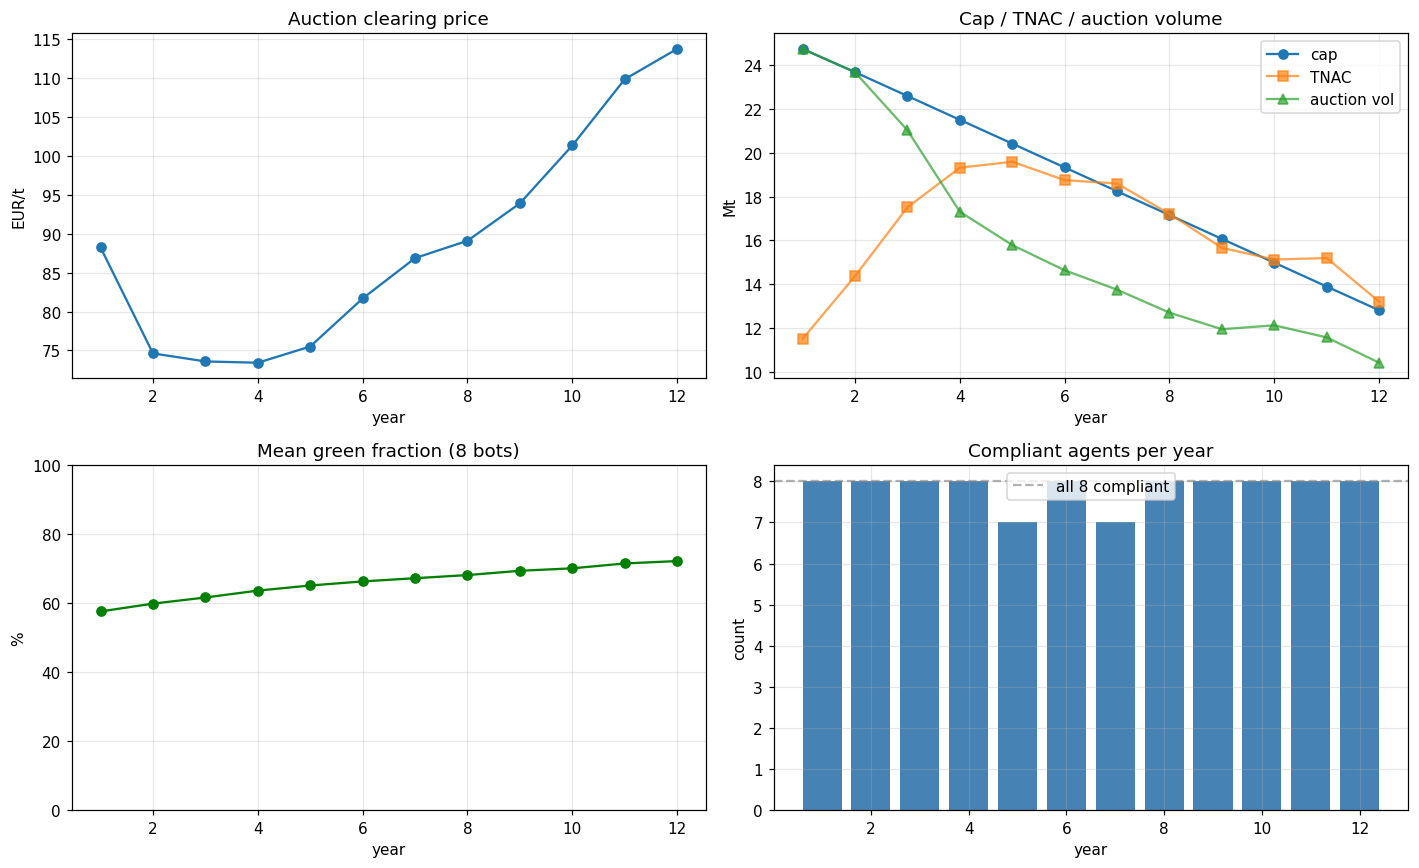

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
ax.plot(demo_df['year'], demo_df['clearing_price'], 'o-')
ax.set_title('Auction clearing price'); ax.set_xlabel('year'); ax.set_ylabel('EUR/t')
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(demo_df['year'], demo_df['cap'], 'o-', label='cap')
ax.plot(demo_df['year'], demo_df['tnac'], 's-', label='TNAC', alpha=0.7)
ax.plot(demo_df['year'], demo_df['auction_volume'], '^-', label='auction vol', alpha=0.7)
ax.set_title('Cap / TNAC / auction volume'); ax.set_xlabel('year'); ax.set_ylabel('Mt')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(demo_df['year'], demo_df['mean_green_frac'] * 100, 'o-', color='green')
ax.set_title('Mean green fraction (8 bots)'); ax.set_xlabel('year'); ax.set_ylabel('%')
ax.set_ylim(0, 100); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.bar(demo_df['year'], demo_df['compliant_agents'], color='steelblue')
ax.axhline(n_bots, ls='--', color='gray', alpha=0.6, label=f'all {n_bots} compliant')
ax.set_title('Compliant agents per year'); ax.set_xlabel('year'); ax.set_ylabel('count')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## 4. Multi-seed run

Run the heuristic market for many episodes per seed. Each episode has fresh stochasticity (per-bot valuation noise, urgency multipliers, demand shocks, construction failures), so cross-episode means describe the steady-state market. Logs are written to `results/bots_only/`.

In [ ]:
SEEDS = list(config['simulation']['seeds'])
N_EPISODES = int(config['simulation']['n_episodes'])
OUTPUT_DIR = 'results/bots_only/'

# Bots-only is fast (~1ms / episode); the default 500 episodes × 3 seeds runs in seconds.
# To re-use existing logs without re-running, set RERUN = False.
RERUN = True

if RERUN:
    for seed in SEEDS:
        run_bots_only_seed(
            config=config, seed=seed,
            n_episodes=N_EPISODES,
            output_dir=OUTPUT_DIR,
            run_tag=None,
            log_interval=max(1, N_EPISODES // 10),
        )

print('\nLogs written to:', OUTPUT_DIR)

Market calibration: 8 participants, emissions=22.5 Mt, cap=24.8 Mt
[ETSEnvironment] 0 learning + 8 bot = 8 total agents | cancel_under_subscribed=False
[bots-only seed=1729] starting 10000 episodes — log every 1000
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): B1=2.27, B2=3.11, B3=1.82, B4=2.09, B5=0.83, B6=0.76, B7=0.32, B8=0.30
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=11.49 MtCO2.
[bots-only s=1729] ep     1/10000 | clr̄=  72.8 | comply= 99.0% | green̄= 71.5% | Q=+1.79 | ETA=13:30
[bots-only s=1729] ep  1000/10000 | clr̄= 109.4 | comply= 99.0% | green̄= 73.7% | Q=+0.70 | ETA=09:34
[bots-only s=1729] ep  2000/10000 | clr̄= 108.4 | comply= 94.8% | green̄= 70.3% | Q=+0.22 | ETA=09:22
[bots-only s=1729] ep  3000/10000 | clr̄= 125.2 | comply= 79.2% | green̄= 72.9% | Q=-0.99 | ETA=09:35
[bots-only s=1729] ep  4000/10000 | clr̄= 120.8 | comply= 89.6% | green̄

In [ ]:
# Load all per-seed training logs into a single long frame.
def _load_seed_log(path: str, seed: int) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['seed'] = seed
    return df

train_dfs, year_dfs = [], []
for seed in SEEDS:
    tp = os.path.join(OUTPUT_DIR, f'training_log_s{seed}.csv')
    yp = os.path.join(OUTPUT_DIR, f'year_log_s{seed}.csv')
    if os.path.exists(tp):
        train_dfs.append(_load_seed_log(tp, seed))
    if os.path.exists(yp):
        year_dfs.append(_load_seed_log(yp, seed))

train_df = pd.concat(train_dfs, ignore_index=True)
year_df = pd.concat(year_dfs, ignore_index=True)
print(f'train_df: {len(train_df):,} rows ({train_df["seed"].nunique()} seeds)')
print(f'year_df : {len(year_df):,} rows')
train_df.head(3)

C:\Users\danie\AppData\Local\Temp\ipykernel_17908\723116824.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['seed'] = seed


train_df: 2,000 rows (4 seeds)
year_df : 24,000 rows


,episode,ep_mean_clearing_price,mean_price,price_start,price_peak,price_std,secondary_avg_price,secondary_volume_total,compliance_rate,shortfall_total,...,green_frac_A7,shortfall_A7,penalty_A7,compliance_rate_A7,reward_A8,green_frac_A8,shortfall_A8,penalty_A8,compliance_rate_A8,seed
0,0,72.824054,72.824054,88.798584,88.798584,10.663649,87.429693,8.433507,0.989583,0.024284,...,1.000000,0.0,0.0,1.0,5.946105,1.0,0.0,0.0,1.0,1729
1,1,91.380566,91.380566,95.435608,117.605705,14.036150,99.499187,6.691043,0.989583,0.176004,...,0.995221,0.0,0.0,1.0,4.486322,1.0,0.0,0.0,1.0,1729
2,2,99.794934,99.794934,103.654610,132.248169,16.251575,107.452246,5.965798,0.989583,0.033478,...,1.000000,0.0,0.0,1.0,4.884313,1.0,0.0,0.0,1.0,1729


## 5. Cross-seed market trajectories

For each seed, plot the per-episode market metrics. Heuristic bots don't *learn*, so the curves should be flat-ish bands of stochastic variation — the run-to-run shape is set by the production calibration (cap path, MSR, penalties, ESG), not by training.

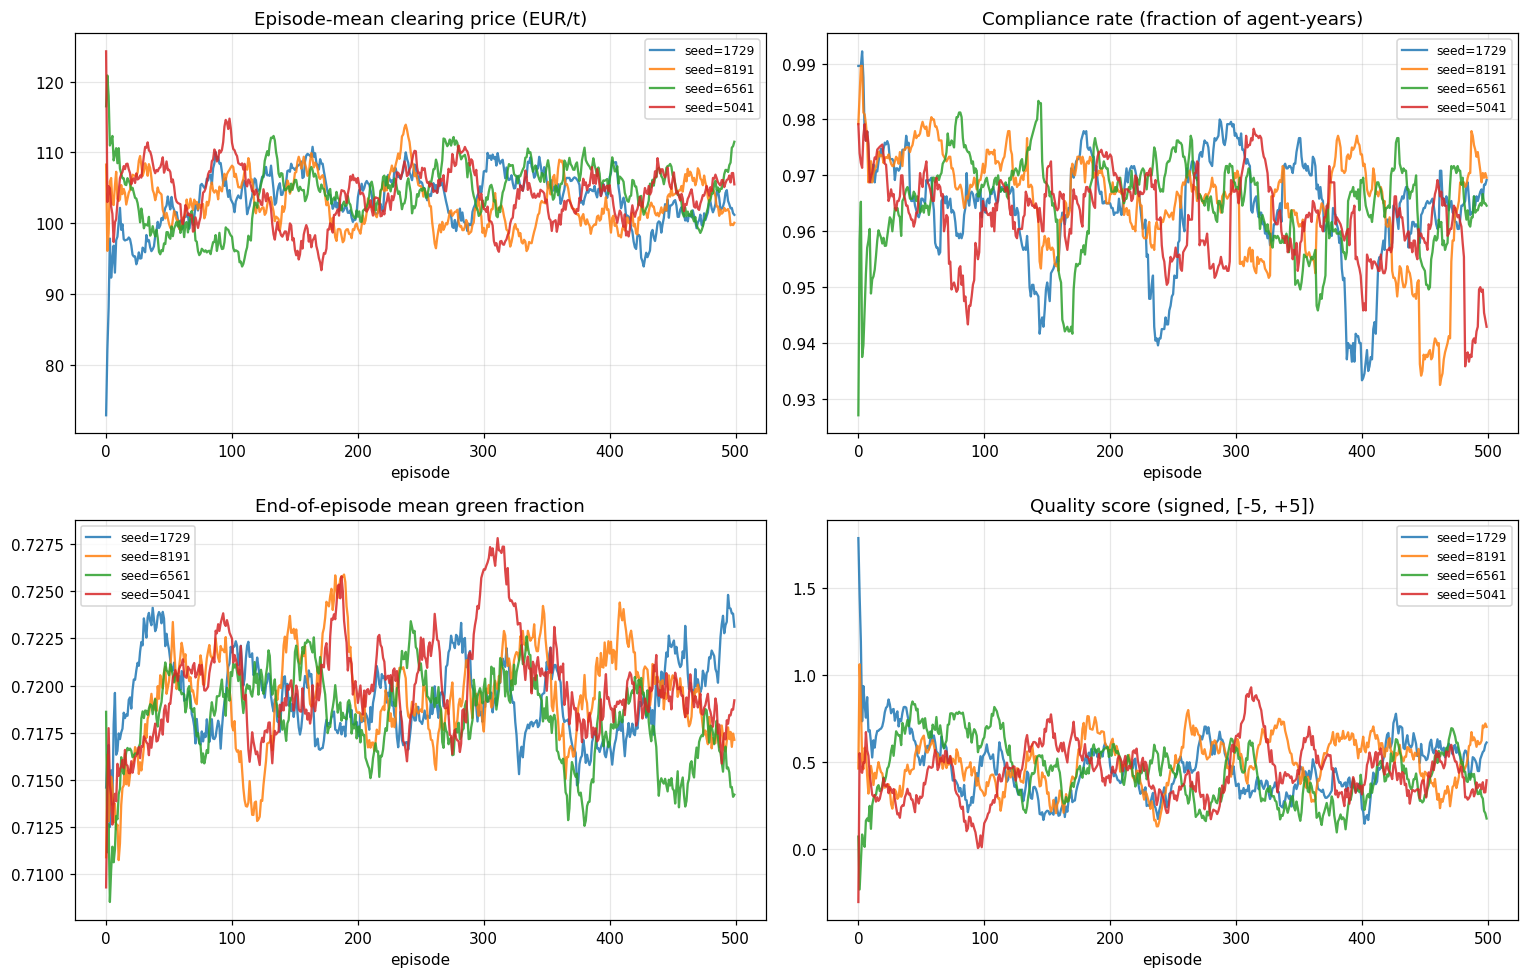

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ('ep_mean_clearing_price', 'Episode-mean clearing price (EUR/t)'),
    ('compliance_rate', 'Compliance rate (fraction of agent-years)'),
    ('mean_green_frac', 'End-of-episode mean green fraction'),
    ('quality_score', 'Quality score (signed, [-5, +5])'),
]
for ax, (col, title) in zip(axes.flat, metrics):
    for seed in SEEDS:
        sd = train_df[train_df['seed'] == seed]
        if col not in sd.columns:
            continue
        ax.plot(sd['episode'], sd[col].rolling(window=max(5, len(sd) // 20), min_periods=1).mean(),
                label=f'seed={seed}', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('episode')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()

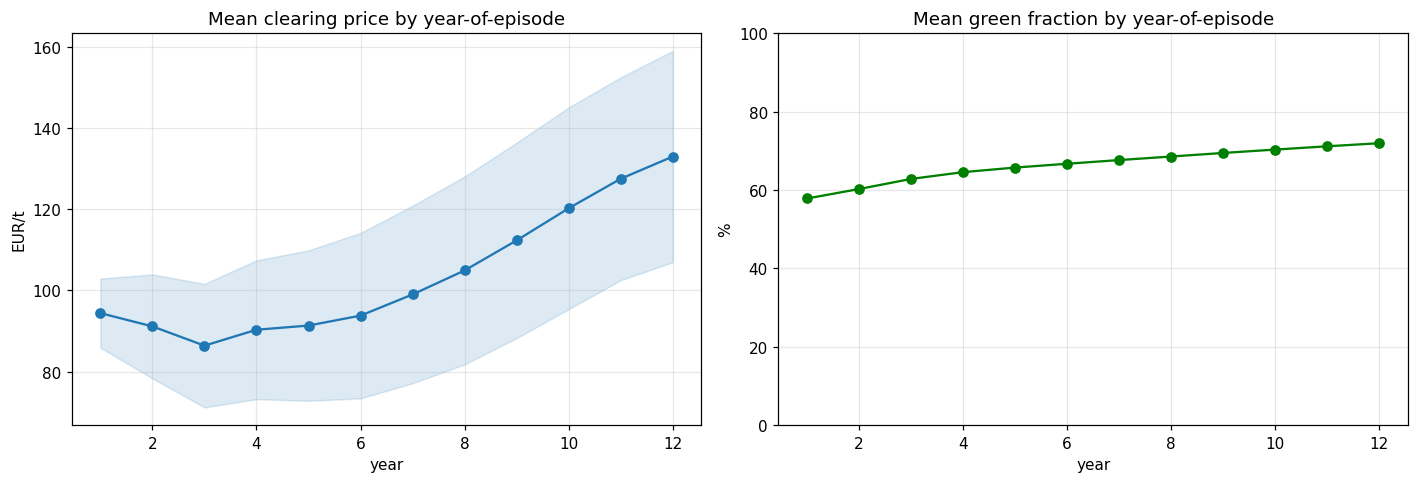

In [ ]:
# Year-of-episode price profile, averaged across all (episode, seed)
year_price = year_df.groupby('year')['clearing_price'].agg(['mean', 'std']).reset_index()
year_green = year_df.groupby('year')[[f'green_frac_A{i+1}' for i in range(n_total)]].mean().mean(axis=1).reset_index()
year_green.columns = ['year', 'mean_green_frac']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(year_price['year'] + 1, year_price['mean'], 'o-', color='C0')
ax.fill_between(year_price['year'] + 1,
                year_price['mean'] - year_price['std'],
                year_price['mean'] + year_price['std'],
                color='C0', alpha=0.15)
ax.set_title('Mean clearing price by year-of-episode')
ax.set_xlabel('year'); ax.set_ylabel('EUR/t'); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(year_green['year'] + 1, year_green['mean_green_frac'] * 100, 'o-', color='green')
ax.set_title('Mean green fraction by year-of-episode')
ax.set_xlabel('year'); ax.set_ylabel('%'); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
plt.tight_layout()

## 6. Per-bot performance

Summary table over the last 25% of episodes per seed, then averaged across seeds. The four archetype pairs (coal-heavy, gas-dominant, transitioner, green-leader) split into financial / ESG variants by reward weights — financial bots minimise costs, ESG bots also pay attention to green share.

In [ ]:
tail_frac = 0.25
def _last_window(df, frac=tail_frac):
    cutoff = int(len(df) * (1 - frac))
    return df.iloc[cutoff:]

archetypes = ['coal-h/fin', 'coal-h/ESG', 'gas-d/fin', 'gas-d/ESG',
              'trans/fin', 'trans/ESG', 'green-l/fin', 'green-l/ESG']

rows = []
for i in range(n_total):
    name = archetypes[i] if i < len(archetypes) else f'B{i+1}'
    row = {'bot': f'B{i+1}', 'archetype': name}
    for col, label in [('reward', 'reward'),
                       ('green_frac', 'green%'),
                       ('shortfall', 'shortfall'),
                       ('penalty', 'penalty (M€)'),
                       ('compliance_rate', 'comply%')]:
        c = f'{col}_A{i+1}'
        if c not in train_df.columns:
            row[label] = np.nan; continue
        per_seed = []
        for seed in SEEDS:
            sd = _last_window(train_df[train_df['seed'] == seed])
            per_seed.append(sd[c].mean())
        v = float(np.mean(per_seed))
        if col in ('green_frac', 'compliance_rate'):
            v *= 100
        row[label] = round(v, 3)
    rows.append(row)

summary = pd.DataFrame(rows)
summary

,bot,archetype,reward,green%,shortfall,penalty (M€),comply%
0,B1,coal-h/fin,-6.302,32.371,0.129,20.461,98.733
1,B2,coal-h/ESG,-0.898,45.471,0.093,15.184,98.950
2,B3,gas-d/fin,-1.771,51.493,0.195,31.639,97.233
3,B4,gas-d/ESG,1.578,66.671,0.100,16.623,98.367
4,B5,trans/fin,-2.338,82.068,0.136,22.124,95.883
5,B6,trans/ESG,2.817,97.754,0.096,15.521,94.350
6,B7,green-l/fin,-4.383,99.314,0.191,30.235,87.933
7,B8,green-l/ESG,3.610,100.000,0.042,6.371,96.383


## 7. Comparison with Q-learning and PPO sweep (optional)

If the Q-learning baseline (`results/qlearning/ql_training_log_s*.csv`) and/or the default-config PPO sweep (`results/sweep_default_seeds/.../training_log_s*.csv`) have been run, place the bots-only floor next to them.

**Apples-to-apples note.** The three sources run for very different episode budgets (bots-only: 500/seed, Q-learning: typically 5–10k, PPO/HAPPO: 100k). Bots also don't *learn* — their 500 episodes are i.i.d. samples of a steady-state market, not a convergence trajectory. Plotting per-episode curves on a shared episode axis is therefore misleading. We make the comparison fair in two ways:

1. **Bots as a reference band, learners as curves.** Bots collapse to a horizontal mean ± std band (over all their episodes across seeds). Q-learning and PPO are plotted on a normalised training-progress axis (`progress = episode / max_episode_per_seed`), so their learning shapes are directly comparable to each other and the bots' floor is visible as a constant.
2. **Converged-window bar comparison.** All three sources are summarised on the *last 10% of their own episodes per seed* — i.e. each source's own steady state — and shown as bars with cross-seed error bars. This is the only honest single-number comparison.

In [ ]:
# Q-learning logs
ql_paths = sorted(glob.glob('results/qlearning/ql_training_log_s*.csv'))
ql_dfs = []
for p in ql_paths:
    try:
        seed = int(p.split('_s')[-1].split('.csv')[0])
    except ValueError:
        continue
    df = pd.read_csv(p); df['seed'] = seed
    ql_dfs.append(df)
ql_df = pd.concat(ql_dfs, ignore_index=True) if ql_dfs else None
print(f'Q-learning logs: {len(ql_paths)} seed(s)' if ql_df is not None else 'Q-learning: not found')

# PPO default-seed sweep
ppo_paths = sorted(glob.glob('results/sweep_default_seeds/*/training_log_s*.csv'))
if not ppo_paths:
    ppo_paths = sorted(glob.glob('results/training_log_s*.csv'))
ppo_dfs = []
for p in ppo_paths:
    try:
        seed = int(p.rsplit('_s', 1)[-1].split('.csv')[0])
    except ValueError:
        continue
    df = pd.read_csv(p); df['seed'] = seed
    ppo_dfs.append(df)
ppo_df = pd.concat(ppo_dfs, ignore_index=True) if ppo_dfs else None
print(f'PPO logs: {len(ppo_paths)} seed(s)' if ppo_df is not None else 'PPO: not found')

C:\Users\danie\AppData\Local\Temp\ipykernel_17908\2061574892.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = pd.read_csv(p); df['seed'] = seed


Q-learning logs: 1 seed(s)


C:\Users\danie\AppData\Local\Temp\ipykernel_17908\2061574892.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = pd.read_csv(p); df['seed'] = seed


PPO logs: 9 seed(s)


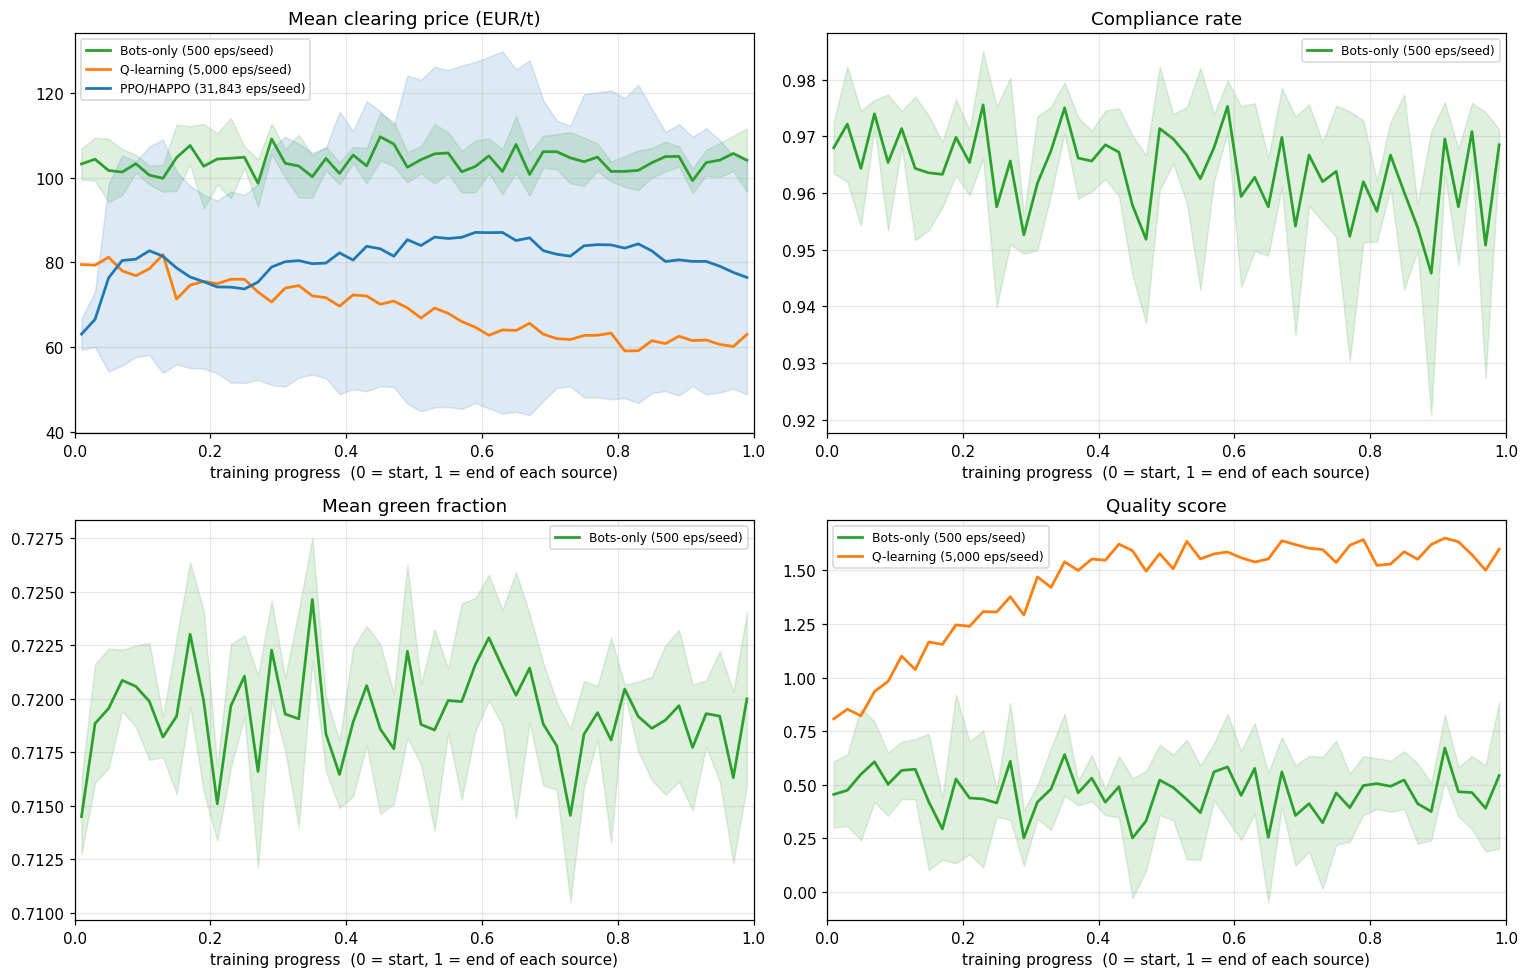

In [ ]:
# Apples-to-apples: all three sources are binned onto the same normalised
# training-progress axis [0, 1] and averaged across seeds, so the per-source
# episode budget (500 vs 5k vs 100k) is factored out. Bots aren't deterministic
# (valuation noise, demand shocks, construction failures), so they get the SAME
# processing as the learners — their flatness on this axis is the evidence that
# they don't learn, not an assumption baked into the plotting.

def _band_normalized(df, col, n_bins=50):
    """Bin episodes per seed onto [0, 1] training progress, then average across seeds."""
    if df is None or col not in df.columns:
        return None
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    per_seed = []
    for seed in df['seed'].unique():
        sd = df[df['seed'] == seed].sort_values('episode').reset_index(drop=True)
        if len(sd) < 2:
            continue
        progress = np.arange(len(sd)) / max(1, len(sd) - 1)
        idx = np.clip(np.digitize(progress, bins) - 1, 0, n_bins - 1)
        binned = pd.Series(sd[col].values).groupby(idx).mean()
        binned = binned.reindex(range(n_bins)).interpolate(limit_direction='both')
        per_seed.append(binned.values)
    if not per_seed:
        return None
    M = np.vstack(per_seed)
    return centers, np.nanmean(M, axis=0), np.nanstd(M, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
panels = [
    ('ep_mean_clearing_price', 'Mean clearing price (EUR/t)'),
    ('compliance_rate',        'Compliance rate'),
    ('mean_green_frac',        'Mean green fraction'),
    ('quality_score',          'Quality score'),
]

sources = [
    ('Bots-only',  train_df, 'C2'),
    ('Q-learning', ql_df,    'C1'),
    ('PPO/HAPPO',  ppo_df,   'C0'),
]

for ax, (col, title) in zip(axes.flat, panels):
    for label, df, color in sources:
        if df is None:
            continue
        n_eps = int(df.groupby('seed').size().mean()) if 'seed' in df.columns else len(df)
        b = _band_normalized(df, col)
        if b is None:
            continue
        x, m, s = b
        ax.plot(x, m, color=color, lw=1.8, label=f'{label} ({n_eps:,} eps/seed)')
        ax.fill_between(x, m - s, m + s, color=color, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('training progress  (0 = start, 1 = end of each source)')
    ax.set_xlim(0.0, 1.0)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)
plt.tight_layout()

In [ ]:
# Converged-window comparison: each source uses the last 10% of its OWN episodes
# per seed. This is the only single-number comparison that's apples-to-apples,
# because every source is summarised on its own steady state regardless of
# total episode budget.
COMPARE_COLS = ('ep_mean_clearing_price', 'compliance_rate', 'mean_green_frac', 'quality_score')

def _converged_summary(df, label, cols=COMPARE_COLS, tail_frac=0.10):
    rows = []
    for seed in df['seed'].unique():
        sd = df[df['seed'] == seed].sort_values('episode')
        tail = sd.iloc[int(len(sd) * (1 - tail_frac)):]
        rows.append({'source': label, 'seed': seed, 'n_episodes': len(sd),
                     **{c: tail[c].mean() if c in tail.columns else np.nan for c in cols}})
    return pd.DataFrame(rows)

frames = [_converged_summary(train_df, 'Bots-only')]
if ql_df is not None:
    frames.append(_converged_summary(ql_df, 'Q-learning'))
if ppo_df is not None:
    frames.append(_converged_summary(ppo_df, 'PPO/HAPPO'))

cmp = pd.concat(frames, ignore_index=True)
print('Per-seed converged-window values (last 10% of episodes per seed):')
print(cmp.round(3).to_string(index=False))

# Cross-seed mean ± std table
cmp_agg = cmp.groupby('source')[list(COMPARE_COLS)].agg(['mean', 'std']).round(3)

# Bar chart: one panel per metric, one bar per source, error bars = cross-seed std
sources = cmp['source'].unique().tolist()
colors = {'Bots-only': 'C2', 'Q-learning': 'C1', 'PPO/HAPPO': 'C0'}
labels = {
    'ep_mean_clearing_price': 'Mean clearing price (EUR/t)',
    'compliance_rate':        'Compliance rate',
    'mean_green_frac':        'Mean green fraction',
    'quality_score':          'Quality score',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, col in zip(axes, COMPARE_COLS):
    means = [cmp[cmp['source'] == s][col].mean() for s in sources]
    stds  = [cmp[cmp['source'] == s][col].std(ddof=0) for s in sources]
    bars = ax.bar(sources, means, yerr=stds, capsize=6,
                  color=[colors.get(s, 'gray') for s in sources],
                  edgecolor='black', linewidth=0.6, alpha=0.85)
    # annotate per-source episode budget on each bar
    for bar, src in zip(bars, sources):
        n_eps = int(cmp[cmp['source'] == src]['n_episodes'].mean())
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'\n{n_eps:,} eps', ha='center', va='bottom', fontsize=7, color='dimgray')
    ax.set_title(labels[col], fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=9)
plt.suptitle('Converged-window comparison (last 10% of each source\'s episodes; error bars = cross-seed std)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

cmp_agg

seed           ep_mean_clearing_price         compliance_rate  \
                mean       std                   mean     std            mean   
source                                                                          
Bots-only   5380.500  2753.253                103.334   2.297           0.963   
PPO/HAPPO    406.778   324.630                 78.721  30.797             NaN   
Q-learning    42.000       NaN                    NaN     NaN             NaN   

                  mean_green_frac        quality_score        
              std            mean    std          mean   std  
source                                                        
Bots-only   0.007           0.719  0.003         0.507  0.09  
PPO/HAPPO     NaN             NaN    NaN           NaN   NaN  
Q-learning    NaN             NaN    NaN           NaN   NaN

## 8. Takeaways

* **Bots-only as a credibility floor.** The heuristic-bots-only market is fully rule-based: each bot's bid is a willingness-to-pay between MAC and the inflation-adjusted penalty cap, with NPV-gated investment and budget-headroom-aware secondary trading. There is no learning. Cross-seed quality bands describe the *production calibration on its own*, before any agent gets to optimise against it.

* **Comparison logic.**
  * If Q-learning ≈ bots → the discrete coordination problem is too easy for tabular methods to differentiate from rules.
  * If PPO/HAPPO ≈ bots → the simulation isn't pushing learners to find non-trivial strategies (calibration / reward-shape problem).
  * If PPO/HAPPO > Q-learning > bots → the agent space is doing useful work; the gaps measure exactly how much.

* **What the bots are good at:** compliance under default-config calibration, sensible price discovery (clearing tracks fundamentals), and a moderate green transition (~70% by year 12).

* **What the bots are bad at:** strategic banking, secondary-market timing (the heuristic is fundamentals-only), and exploiting cap-scarcity windfalls. These are the strategy gaps the learning agents are expected to close.